# Topic : Feature Engineering

Group Members:

1)
*   Name: Md Yaseen Alam
*   PRN: 202201040060
*  Batch: A1
*  MSID: 17

2)
*   Name: Vaibhav Satish Jadhav
*   PRN: 202201040027
*  Batch: A1
*  MSID: 04

3)
*   Name: Mayur Ashok Kapgate
*   PRN: 202201040065
*  Batch: A1
*  MSID: 21


DATASET LINK:https://drive.google.com/file/d/1eDCW78VUmTq5yof9VA4xbk2asy8rTDNk/
view?usp=drive_link

Colab: https://colab.research.google.com/drive/1Ogk9hiUFA9Asar5b1HsvK-lY3bPgpLfZ?usp=sharing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/survey_lung_cancer_expanded.csv")

In [4]:
print(f"Shape of The Dataset : {df.shape}")

Shape of The Dataset : (9000, 16)


In [5]:
# Data types of columns
print("\nDataset information (column data types and non-null counts):")
df.info()


Dataset information (column data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 9000 non-null   object
 1   AGE                    9000 non-null   int64 
 2   SMOKING                9000 non-null   int64 
 3   YELLOW_FINGERS         9000 non-null   int64 
 4   ANXIETY                9000 non-null   int64 
 5   PEER_PRESSURE          9000 non-null   int64 
 6   CHRONIC DISEASE        9000 non-null   int64 
 7   FATIGUE                9000 non-null   int64 
 8   ALLERGY                9000 non-null   int64 
 9   WHEEZING               9000 non-null   int64 
 10  ALCOHOL CONSUMING      9000 non-null   int64 
 11  COUGHING               9000 non-null   int64 
 12  SHORTNESS OF BREATH    9000 non-null   int64 
 13  SWALLOWING DIFFICULTY  9000 non-null   int64 
 14  CHEST PAIN

In [6]:
# Statistics of the numerical columns
print("\nDescriptive statistics for the numerical columns:")
df.describe()


Descriptive statistics for the numerical columns:


,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,62.713778,1.541333,1.542444,1.496667,1.495000,1.506556,1.609889,1.536778,1.542111,1.536889,1.548778,1.588333,1.488556,1.535222
std,8.782659,0.498316,0.498223,0.500017,0.500003,0.499985,0.487802,0.498673,0.498251,0.498665,0.497643,0.492163,0.499897,0.498786
min,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,63.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,68.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,92.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [7]:
df.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


In [9]:
palette = ["#1d7874","#679289","#f4c095","#ee2e31","#ffb563","#918450","#f85e00","#a41623","#9a031e","#d6d6d6","#ffee32","#ffd100","#333533","#202020"]

# sns.palplot(sns.color_palette(palette))
# plt.show()

In [10]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


Digging Deeper

In [11]:
# Create a copy of the original DataFrame to avoid modifying the original data
data_temp = df.copy()

# Replace "M" with "Male" and "F" with "Female" in the "GENDER" column
data_temp["GENDER"] = data_temp["GENDER"].replace({"M" : "Male" , "F" : "Female"})

# Loop through each column in the DataFrame
for column in data_temp.columns:
    # Replace the values 2 with "Yes" and 1 with "No" in each column
    data_temp[column] = data_temp[column].replace({2: "Yes" , 1 : "No"})

# Display the first few rows of the modified DataFrame
data_temp.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,Male,69,No,Yes,Yes,No,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,YES
1,Male,74,Yes,No,No,No,Yes,Yes,Yes,No,No,No,Yes,Yes,Yes,YES
2,Female,59,No,No,No,Yes,No,Yes,No,Yes,No,Yes,Yes,No,Yes,NO
3,Male,63,Yes,Yes,Yes,No,No,No,No,No,Yes,No,No,Yes,Yes,NO
4,Female,63,No,Yes,No,No,No,No,No,Yes,No,Yes,Yes,No,No,NO


Positive Lung Cancer Cases

In [12]:
# Filter rows where the "LUNG_CANCER" column has the value "YES" and store it in a new DataFrame
data_temp_pos = data_temp[data_temp["LUNG_CANCER"] == "YES"]

# Display the first few rows of the filtered DataFrame to confirm the results
data_temp_pos.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,Male,69,No,Yes,Yes,No,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,YES
1,Male,74,Yes,No,No,No,Yes,Yes,Yes,No,No,No,Yes,Yes,Yes,YES
5,Female,75,No,Yes,No,No,Yes,Yes,Yes,Yes,No,Yes,Yes,No,No,YES
6,Male,52,Yes,No,No,No,No,Yes,No,Yes,Yes,Yes,Yes,No,Yes,YES
7,Female,51,Yes,Yes,Yes,Yes,No,Yes,Yes,No,No,No,Yes,Yes,No,YES


Positive Cases' Age Distribution

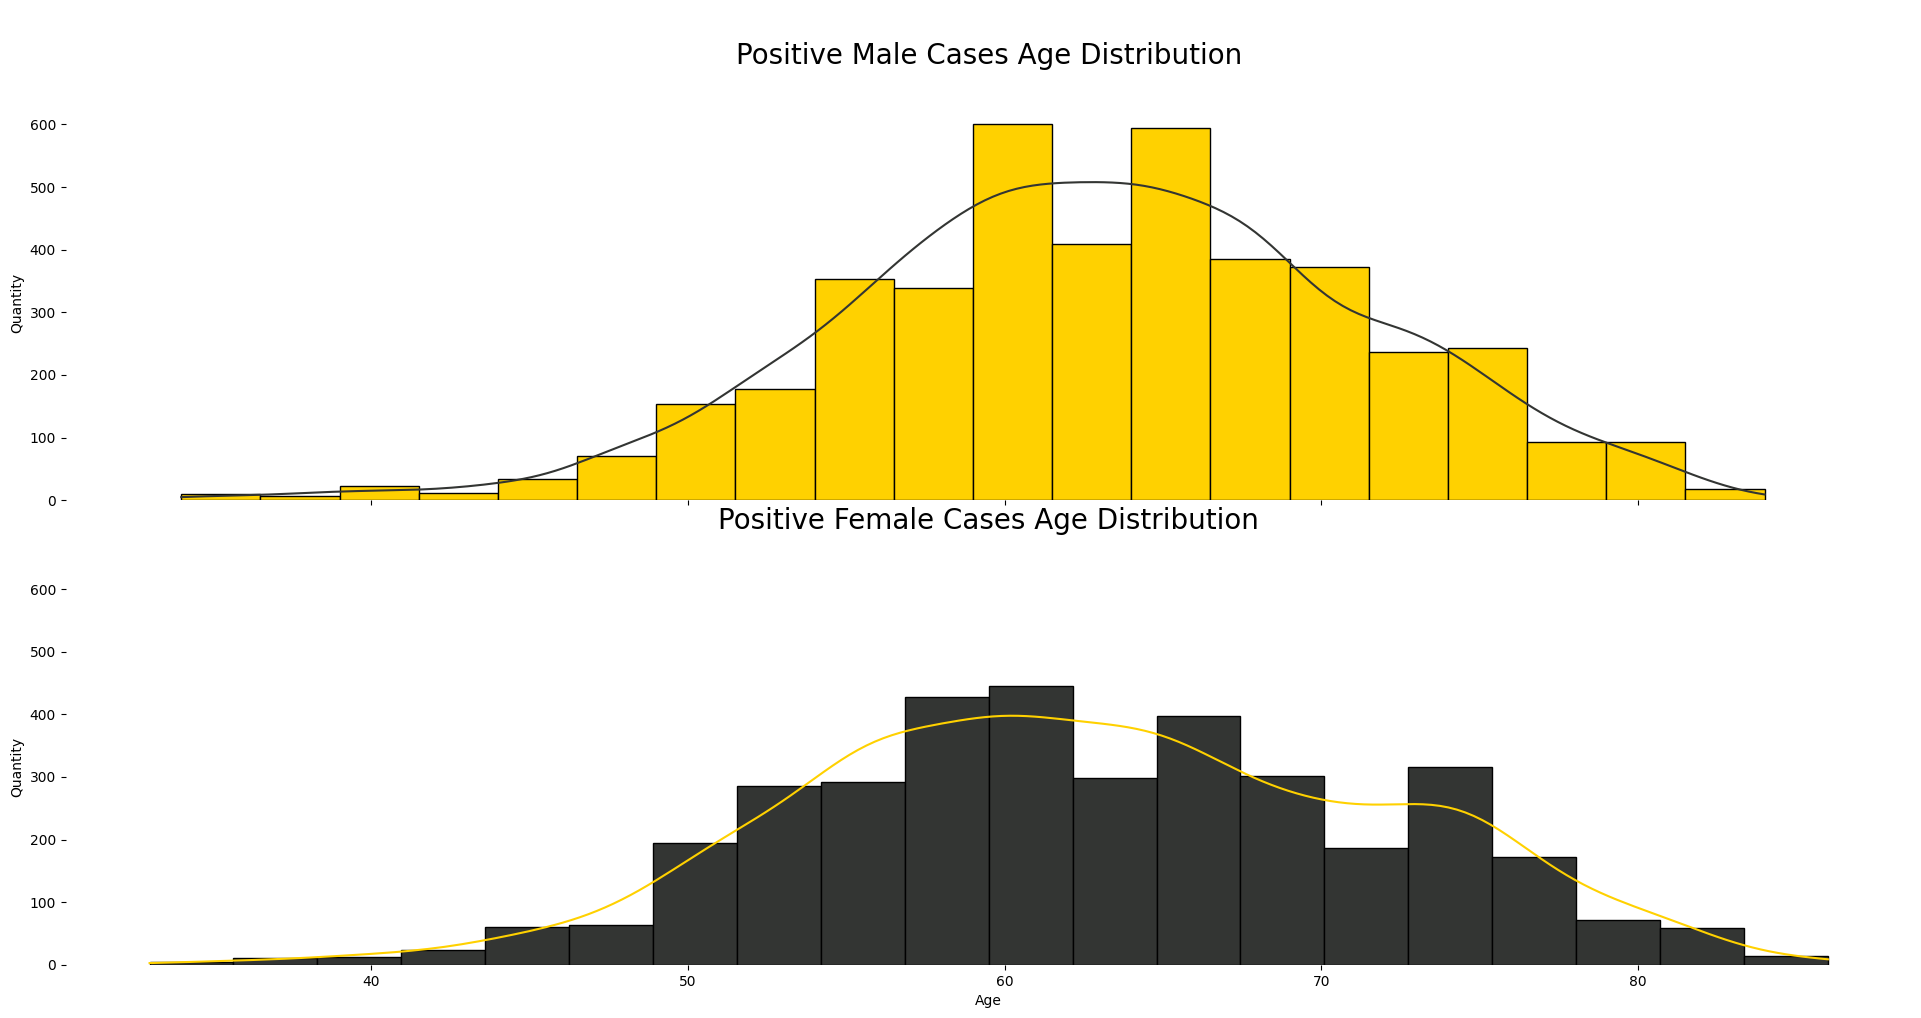

In [13]:
# Create a figure with 2 subplots (2 rows, 1 column), with shared x and y axes
_, axs = plt.subplots(2,1,figsize=(20,10),sharex=True,sharey=True)

# Adjust the layout to avoid overlap between the subplots
plt.tight_layout(pad=4.0)

# Plot the age distribution for male positive cases with KDE (Kernel Density Estimation)
sns.histplot(data_temp_pos[data_temp_pos["GENDER"]=="Male"]["AGE"],
             color=palette[11], kde=True, ax=axs[0], bins=20, alpha=1, fill=True)

# Change the color of the KDE line for male cases
axs[0].lines[0].set_color(palette[12])

# Set the title, x-axis label, and y-axis label for the male age distribution plot
axs[0].set_title("\nPositive Male Cases Age Distribution\n", fontsize=20)
axs[0].set_xlabel("Age")
axs[0].set_ylabel("Quantity")

# Plot the age distribution for female positive cases with KDE
sns.histplot(data_temp_pos[data_temp_pos["GENDER"]=="Female"]["AGE"],
             color=palette[12], kde=True, ax=axs[1], bins=20, alpha=1, fill=True)

# Change the color of the KDE line for female cases
axs[1].lines[0].set_color(palette[11])

# Set the title, x-axis label, and y-axis label for the female age distribution plot
axs[1].set_title("\nPositive Female Cases Age Distribution\n", fontsize=20)
axs[1].set_xlabel("Age")
axs[1].set_ylabel("Quantity")

# Remove the top and right spines (axes lines) for cleaner visual presentation
sns.despine(left=True, bottom=True)

# Show the plot
plt.show()

Lets Stack Them Together In A Same Figure

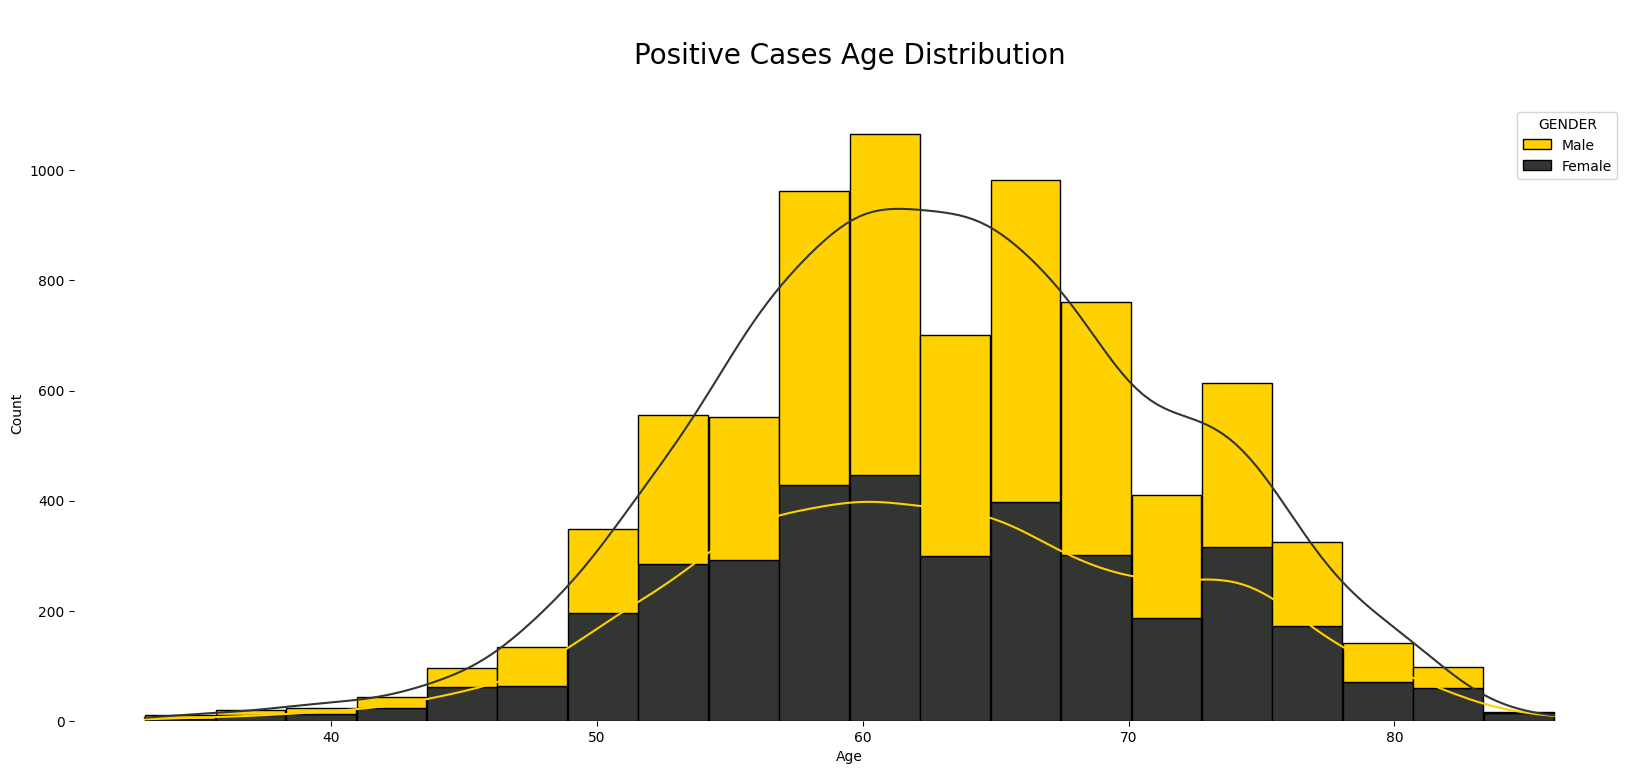

In [14]:
# Create a single plot with a figure size of 20x8 inches
plt.subplots(figsize=(20, 8))

# Plot the stacked histogram for positive cases' age distribution, categorized by gender
p = sns.histplot(data=data_temp_pos, x="AGE", hue="GENDER", multiple="stack",
                 palette=palette[11:13], kde=True, shrink=.99, bins=20, alpha=1, fill=True)

# Change the color of the KDE lines for better contrast
p.axes.lines[0].set_color(palette[11])  # Male KDE line color
p.axes.lines[1].set_color(palette[12])  # Female KDE line color

# Set the title, x-axis label, and y-axis label for the plot
p.axes.set_title("\nPositive Cases Age Distribution\n", fontsize=20)
plt.ylabel("Count")
plt.xlabel("Age")

# Remove the top and right spines for a cleaner look
sns.despine(left=True, bottom=True)

# Show the plot
plt.show()

Positive Cases' Gender Distribution

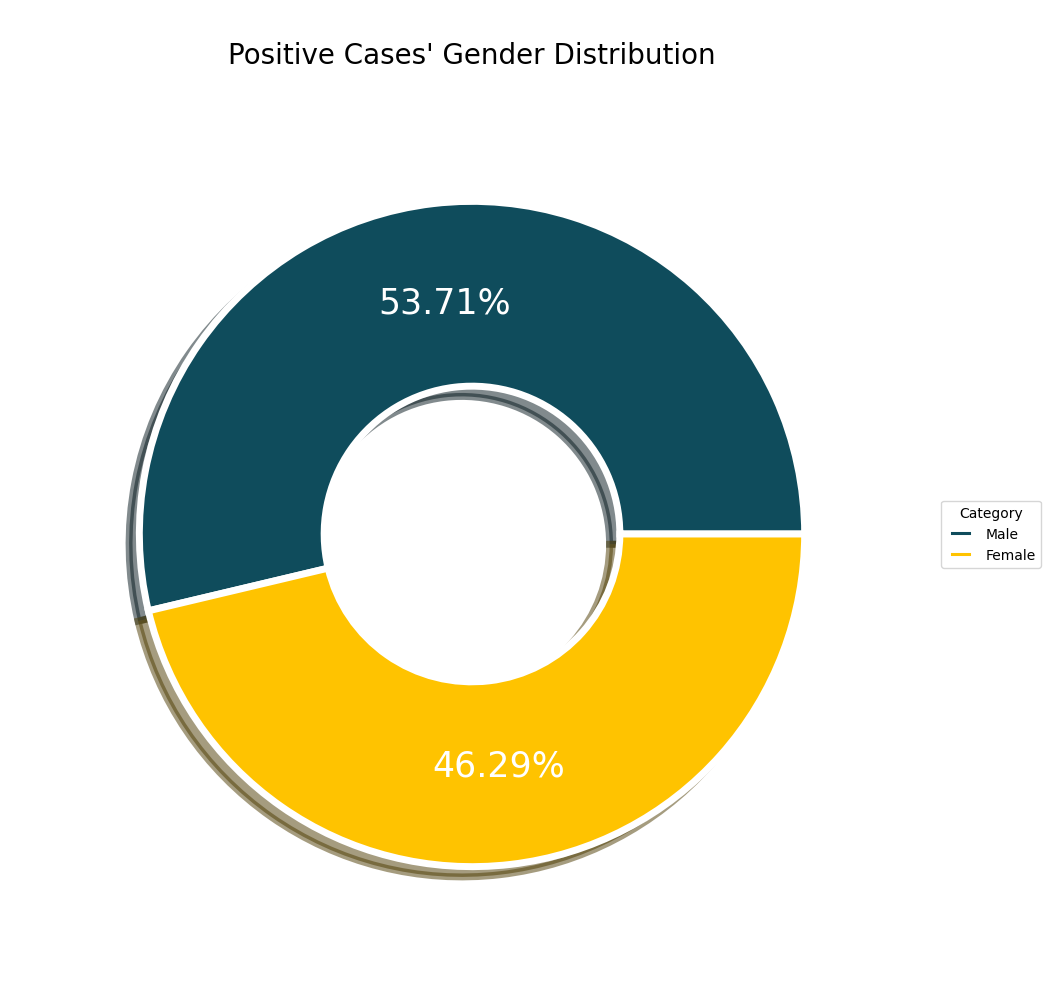

In [15]:
# Create a pie chart with a figure size of 12x12 inches
plt.subplots(figsize=(12, 12))

# Labels for the pie chart representing Male and Female categories
labels = "Male", "Female"

# Set the width of the wedges (pie slices)
size = 0.5

# Create the pie chart
wedges, texts, autotexts = plt.pie([len(data_temp_pos[data_temp_pos["GENDER"]=="Male"]["GENDER"]),
                                    len(data_temp_pos[data_temp_pos["GENDER"]=="Female"]["GENDER"])],
                                    explode = (0, 0),  # No offset for the slices
                                    textprops=dict(size=25, color="white"),  # Text properties for labels
                                    autopct="%.2f%%",  # Display percentage with 2 decimal places
                                    pctdistance=0.7,  # Distance of percentage text from center
                                    radius=.9,  # Set radius of the pie chart
                                    colors=["#0f4c5c", "#FFC300"],  # Colors for Male and Female slices
                                    shadow=True,  # Add shadow for visual effect
                                    wedgeprops=dict(width=size, edgecolor="white", linewidth=5),  # Slice properties
                                    startangle=0)  # Start angle for the pie chart

# Add a legend to the chart
plt.legend(wedges, labels, title="Category", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# Set the title of the chart
plt.title("\nPositive Cases' Gender Distribution", fontsize=20)

# Display the pie chart
plt.show()

Gender-wise Positive Cases' Reasons

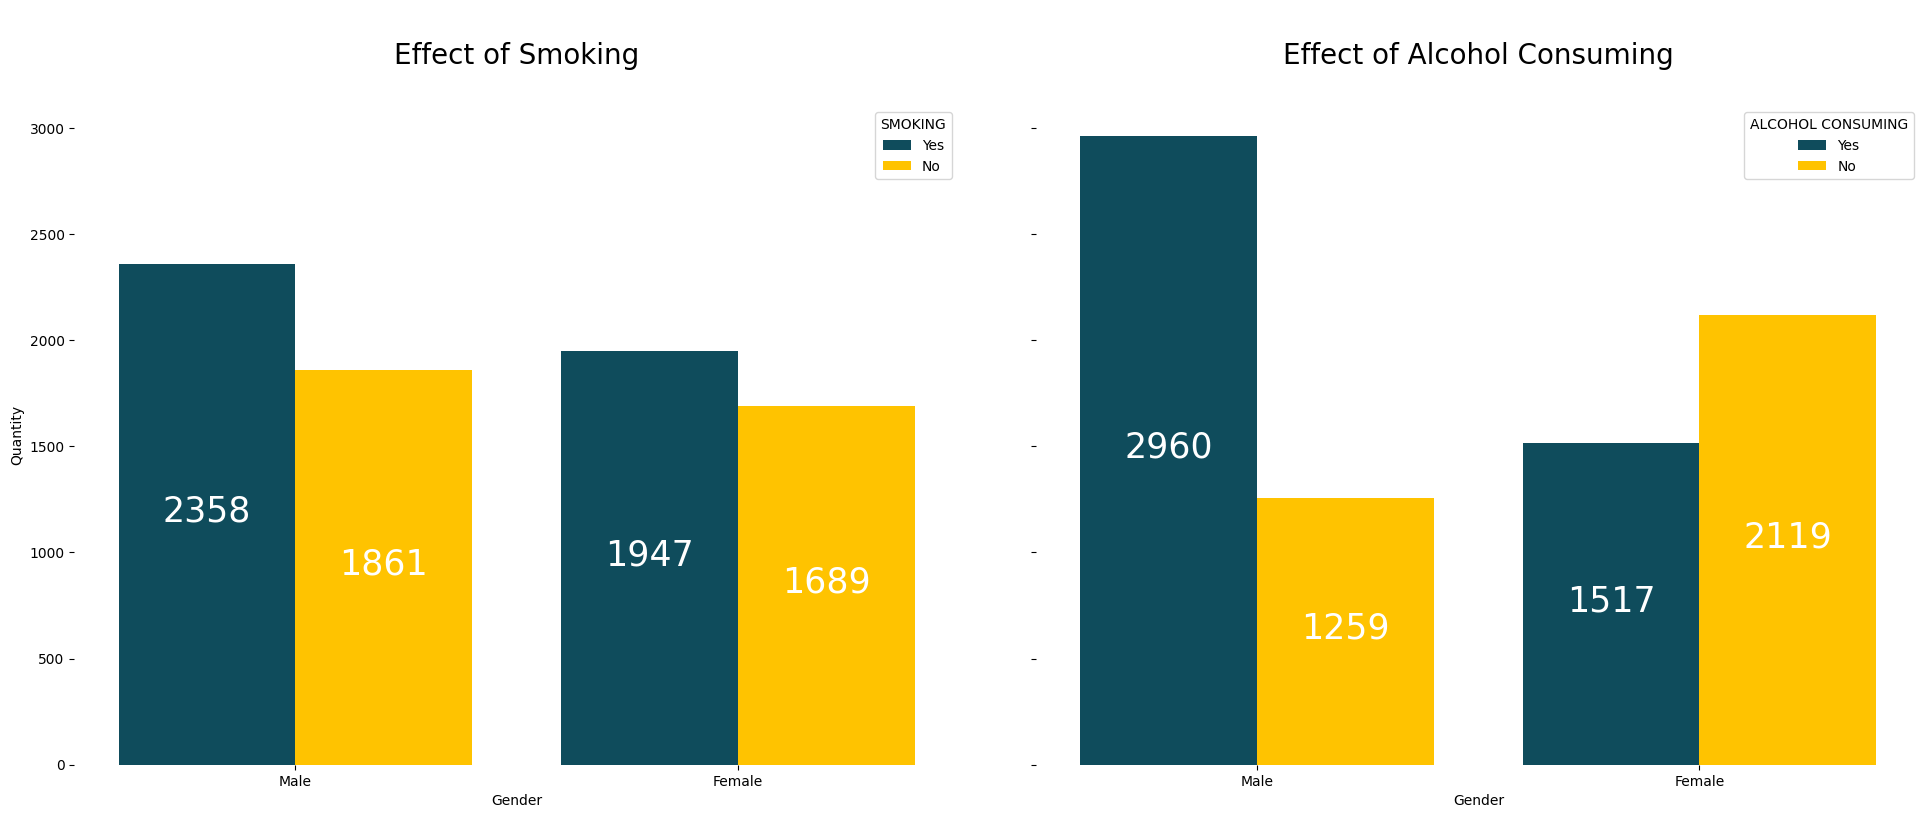

In [17]:
# Create a figure with 1 row and 2 columns of subplots, sharing x and y axes
_, axs = plt.subplots(1,2,figsize=(20,8),sharex=True,sharey=True)

# Adjust the layout to avoid overlap between the subplots
plt.tight_layout(pad=4.0)

# Plot countplot for the effect of smoking on gender, using the "GENDER" column as x-axis and "SMOKING" as hue
sns.countplot(data=data_temp_pos, x="GENDER", hue="SMOKING", hue_order=["Yes", "No"],
              ax=axs[0], palette=["#0f4c5c", "#FFC300"], saturation=1)

# Set the title, x-axis label, and y-axis label for the first plot (Effect of Smoking)
axs[0].set_title("\nEffect of Smoking\n", fontsize=20)
axs[0].set_xlabel("Gender")
axs[0].set_ylabel("Quantity")

# Add labels on top of each bar in the first plot for better clarity
for container in axs[0].containers:
    axs[0].bar_label(container, label_type="center", padding=2, size=25, color="white", rotation=0)

# Plot countplot for the effect of alcohol consumption on gender, using the "GENDER" column as x-axis and "ALCOHOL_CONSUMING" as hue
sns.countplot(data=data_temp_pos, x="GENDER", hue="ALCOHOL CONSUMING", hue_order=["Yes", "No"],
              ax=axs[1], palette=["#0f4c5c", "#FFC300"], saturation=1)

# Set the title, x-axis label, and y-axis label for the second plot (Effect of Alcohol Consumption)
axs[1].set_title("\nEffect of Alcohol Consuming\n", fontsize=20)
axs[1].set_xlabel("Gender")
axs[1].set_ylabel("Quantity")

# Add labels on top of each bar in the second plot for better clarity
for container in axs[1].containers:
    axs[1].bar_label(container, label_type="center", padding=2, size=25, color="white", rotation=0)

# Remove the top and right spines for a cleaner visual presentation
sns.despine(left=True, bottom=True)

# Display the plots
plt.show()

Gender-wise Positive Cases' Symptoms

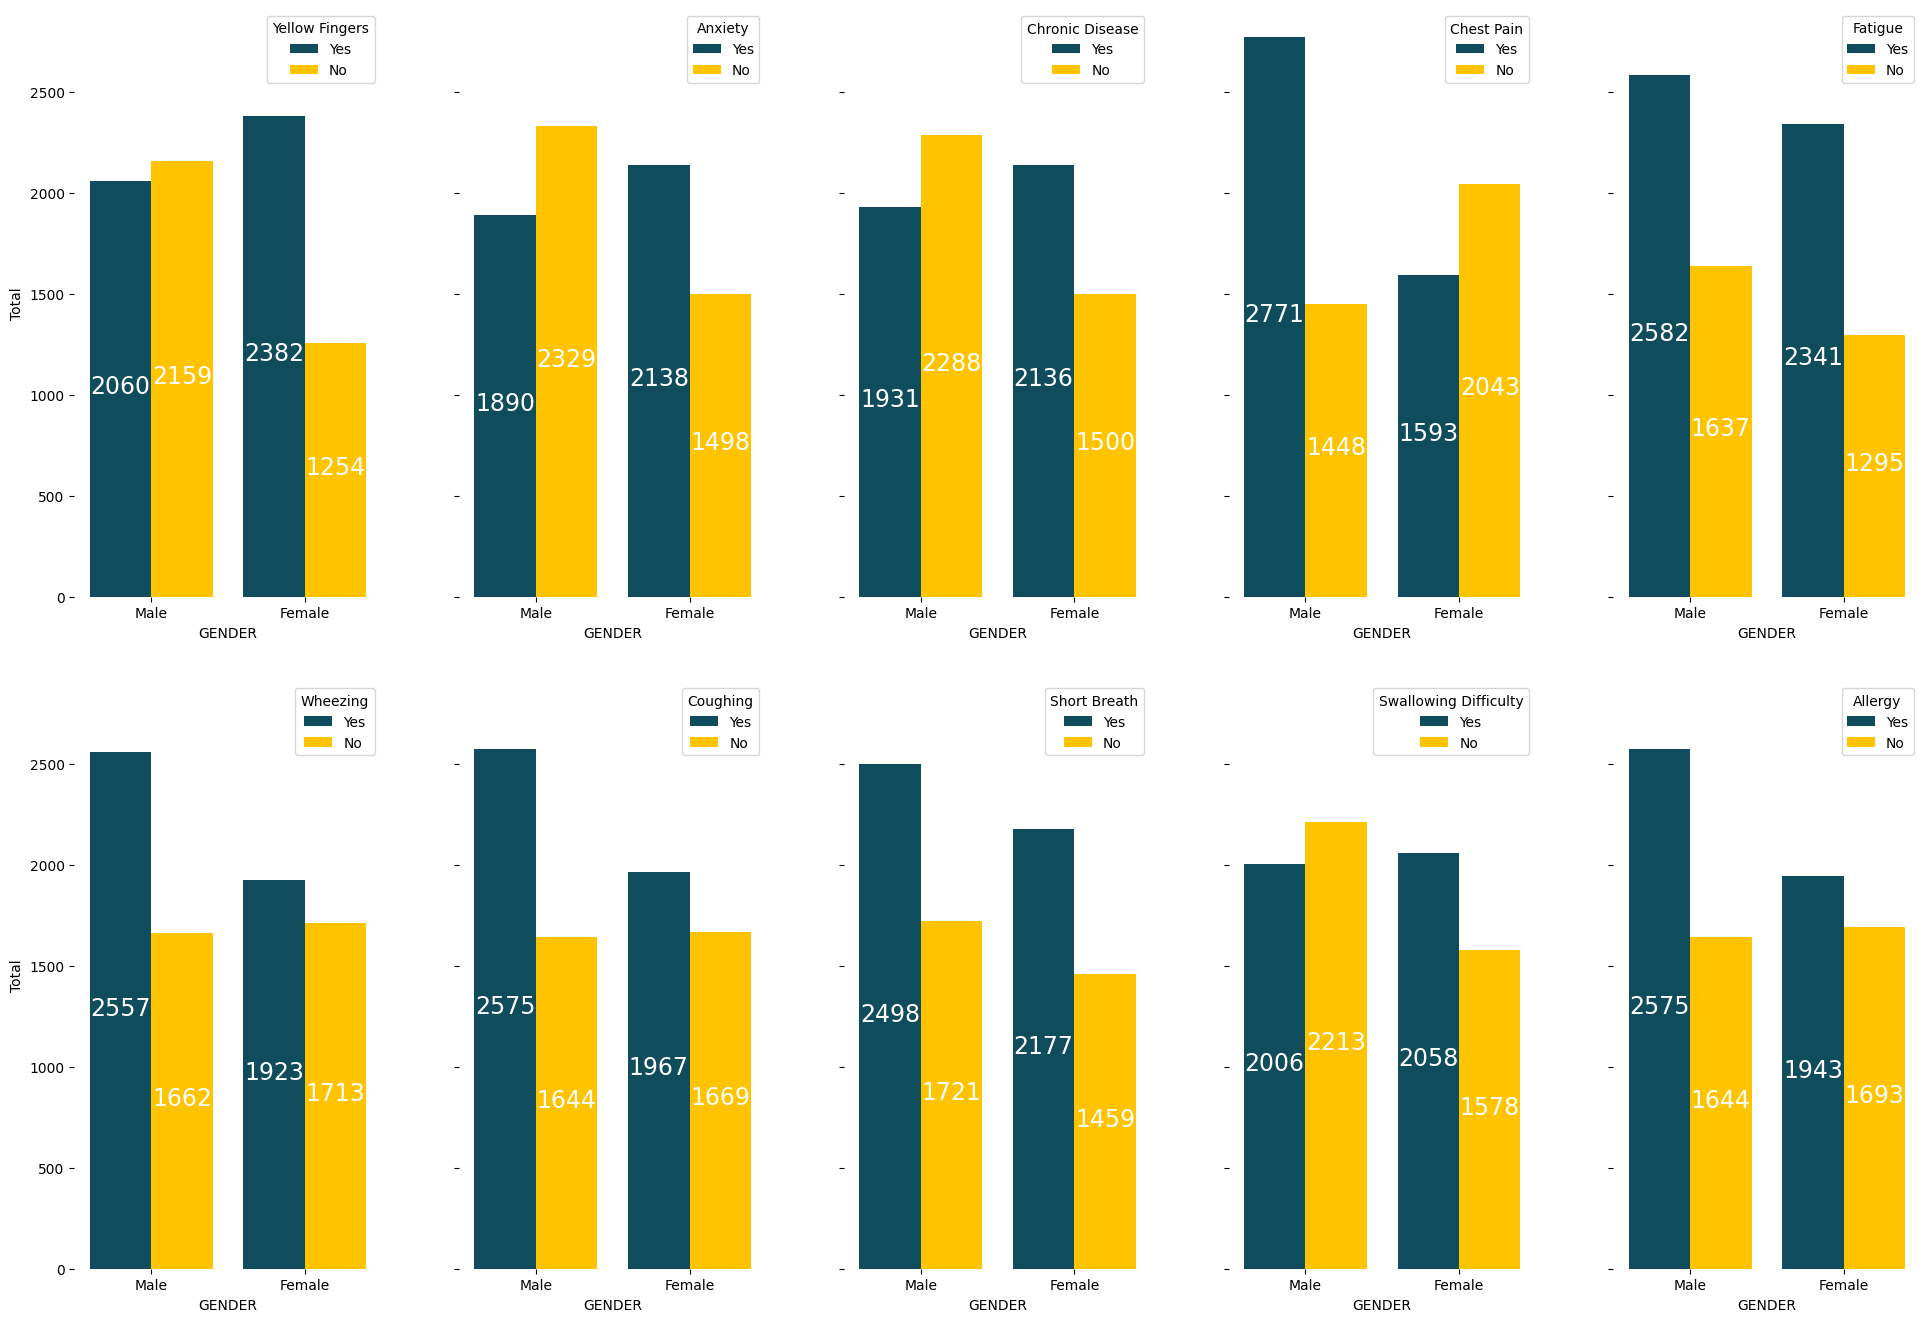

In [23]:
# Create a 2x5 grid of subplots with shared y-axis and individual x-axis for each plot
_, axs = plt.subplots(2,5,figsize=(20,14),sharex=False,sharey=True)

# Adjust the layout to avoid overlap between the subplots
plt.tight_layout(pad=4.0)

# Plot the countplot for "Yellow Fingers" by "GENDER", using the "YELLOW_FINGERS" column as hue
sns.countplot(data=data_temp_pos, x="GENDER", hue="YELLOW_FINGERS", hue_order=["Yes", "No"],
              ax=axs[0,0], palette=["#0f4c5c", "#FFC300"], saturation=1)
axs[0,0].set_ylabel("Total")  # Set the y-axis label
axs[0,0].legend(title="Yellow Fingers", loc="upper right")  # Set the legend
# Add labels on top of each bar to display the counts
for container in axs[0,0].containers:
    axs[0,0].bar_label(container, label_type="center", padding=2, size=17, color="white", rotation=0)

# Plot countplot for "Anxiety" by "GENDER"
sns.countplot(data=data_temp_pos, x="GENDER", hue="ANXIETY", hue_order=["Yes", "No"],
              ax=axs[0,1], palette=["#0f4c5c", "#FFC300"], saturation=1)
axs[0,1].set_ylabel("Total")
axs[0,1].legend(title="Anxiety", loc="upper right")
for container in axs[0,1].containers:
    axs[0,1].bar_label(container, label_type="center", padding=2, size=17, color="white", rotation=0)

# Plot countplot for "Chronic Disease" by "GENDER"
sns.countplot(data=data_temp_pos, x="GENDER", hue="CHRONIC DISEASE", hue_order=["Yes", "No"],
              ax=axs[0,2], palette=["#0f4c5c", "#FFC300"], saturation=1)
axs[0,2].set_ylabel("Total")
axs[0,2].legend(title="Chronic Disease", loc="upper right")
for container in axs[0,2].containers:
    axs[0,2].bar_label(container, label_type="center", padding=2, size=17, color="white", rotation=0)

# Plot countplot for "Chest Pain" by "GENDER"
sns.countplot(data=data_temp_pos, x="GENDER", hue="CHEST PAIN", hue_order=["Yes", "No"],
              ax=axs[0,3], palette=["#0f4c5c", "#FFC300"], saturation=1)
axs[0,3].set_ylabel("Total")
axs[0,3].legend(title="Chest Pain", loc="upper right")
for container in axs[0,3].containers:
    axs[0,3].bar_label(container, label_type="center", padding=2, size=17, color="white", rotation=0)

# Plot countplot for "Fatigue" by "GENDER"
sns.countplot(data=data_temp_pos, x="GENDER", hue="FATIGUE ", hue_order=["Yes", "No"],
              ax=axs[0,4], palette=["#0f4c5c", "#FFC300"], saturation=1)
axs[0,4].set_ylabel("Total")
axs[0,4].legend(title="Fatigue", loc="upper right")
for container in axs[0,4].containers:
    axs[0,4].bar_label(container, label_type="center", padding=2, size=17, color="white", rotation=0)

# Plot countplot for "Wheezing" by "GENDER"
sns.countplot(data=data_temp_pos, x="GENDER", hue="WHEEZING", hue_order=["Yes", "No"],
              ax=axs[1,0], palette=["#0f4c5c", "#FFC300"], saturation=1)
axs[1,0].set_ylabel("Total")
axs[1,0].legend(title="Wheezing", loc="upper right")
for container in axs[1,0].containers:
    axs[1,0].bar_label(container, label_type="center", padding=2, size=17, color="white", rotation=0)

# Plot countplot for "Coughing" by "GENDER"
sns.countplot(data=data_temp_pos, x="GENDER", hue="COUGHING", hue_order=["Yes", "No"],
              ax=axs[1,1], palette=["#0f4c5c", "#FFC300"], saturation=1)
axs[1,1].set_ylabel("Total")
axs[1,1].legend(title="Coughing", loc="upper right")
for container in axs[1,1].containers:
    axs[1,1].bar_label(container, label_type="center", padding=2, size=17, color="white", rotation=0)

# Plot countplot for "Shortness of Breath" by "GENDER"
sns.countplot(data=data_temp_pos, x="GENDER", hue="SHORTNESS OF BREATH", hue_order=["Yes", "No"],
              ax=axs[1,2], palette=["#0f4c5c", "#FFC300"], saturation=1)
axs[1,2].set_ylabel("Total")
axs[1,2].legend(title="Short Breath", loc="upper right")
for container in axs[1,2].containers:
    axs[1,2].bar_label(container, label_type="center", padding=2, size=17, color="white", rotation=0)

# Plot countplot for "Swallowing Difficulty" by "GENDER"
sns.countplot(data=data_temp_pos, x="GENDER", hue="SWALLOWING DIFFICULTY", hue_order=["Yes", "No"],
              ax=axs[1,3], palette=["#0f4c5c", "#FFC300"], saturation=1)
axs[1,3].set_ylabel("Total")
axs[1,3].legend(title="Swallowing Difficulty", loc="upper right")
for container in axs[1,3].containers:
    axs[1,3].bar_label(container, label_type="center", padding=2, size=17, color="white", rotation=0)

# Plot countplot for "Allergy" by "GENDER"
sns.countplot(data=data_temp_pos, x="GENDER", hue="ALLERGY ", hue_order=["Yes", "No"],
              ax=axs[1,4], palette=["#0f4c5c", "#FFC300"], saturation=1)
axs[1,4].set_ylabel("Total")
axs[1,4].legend(title="Allergy", loc="upper right")
for container in axs[1,4].containers:
    axs[1,4].bar_label(container, label_type="center", padding=2, size=17, color="white", rotation=0)

# Remove the top and right spines for a cleaner visual presentation
sns.despine(left=True, bottom=True)

# Display the plots
plt.show()

Correlation Heatmap

In [29]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Read the CSV file into the dataframe
df = pd.read_csv("/content/survey_lung_cancer_expanded.csv")

# Replacing gender values
df["GENDER"] = df["GENDER"].replace({"M": "Male", "F": "Female"})

# Label encoding for 'LUNG_CANCER'
df["LUNG_CANCER"] = label_encoder.fit_transform(df["LUNG_CANCER"])

# Get dummies for 'GENDER' and rename columns
df = pd.get_dummies(df, columns=["GENDER"])
df.rename(columns={
    "GENDER_Male": "MALE",
    "GENDER_Female": "FEMALE",
    "YELLOW_FINGERS": "YELLOW FINGERS",
    "PEER_PRESSURE": "PEER PRESSURE",
    "LUNG_CANCER": "LUNG CANCER",
    "FATIGUE": "FATIGUE",  # Corrected extra space
    "ALLERGY": "ALLERGY"   # Corrected extra space
}, inplace=True)

# Reordering columns
df = df[[
    "AGE", "MALE", "FEMALE", "ALCOHOL CONSUMING", "CHEST PAIN",
    "SHORTNESS OF BREATH", "COUGHING", "PEER PRESSURE", "CHRONIC DISEASE",
    "SWALLOWING DIFFICULTY", "YELLOW FINGERS", "ANXIETY", "FATIGUE ",
    "ALLERGY ", "WHEEZING", "LUNG CANCER"
]]

# Displaying the styled DataFrame
df.head()

,AGE,MALE,FEMALE,ALCOHOL CONSUMING,CHEST PAIN,SHORTNESS OF BREATH,COUGHING,PEER PRESSURE,CHRONIC DISEASE,SWALLOWING DIFFICULTY,YELLOW FINGERS,ANXIETY,FATIGUE,ALLERGY,WHEEZING,LUNG CANCER
0,69,True,False,2,2,2,2,1,1,2,2,2,2,1,2,1
1,74,True,False,1,2,2,1,1,2,2,1,1,2,2,1,1
2,59,False,True,1,2,2,2,2,1,1,1,1,2,1,2,0
3,63,True,False,2,2,1,1,1,1,2,2,2,1,1,1,0
4,63,False,True,1,1,2,2,1,1,1,2,1,1,1,2,0


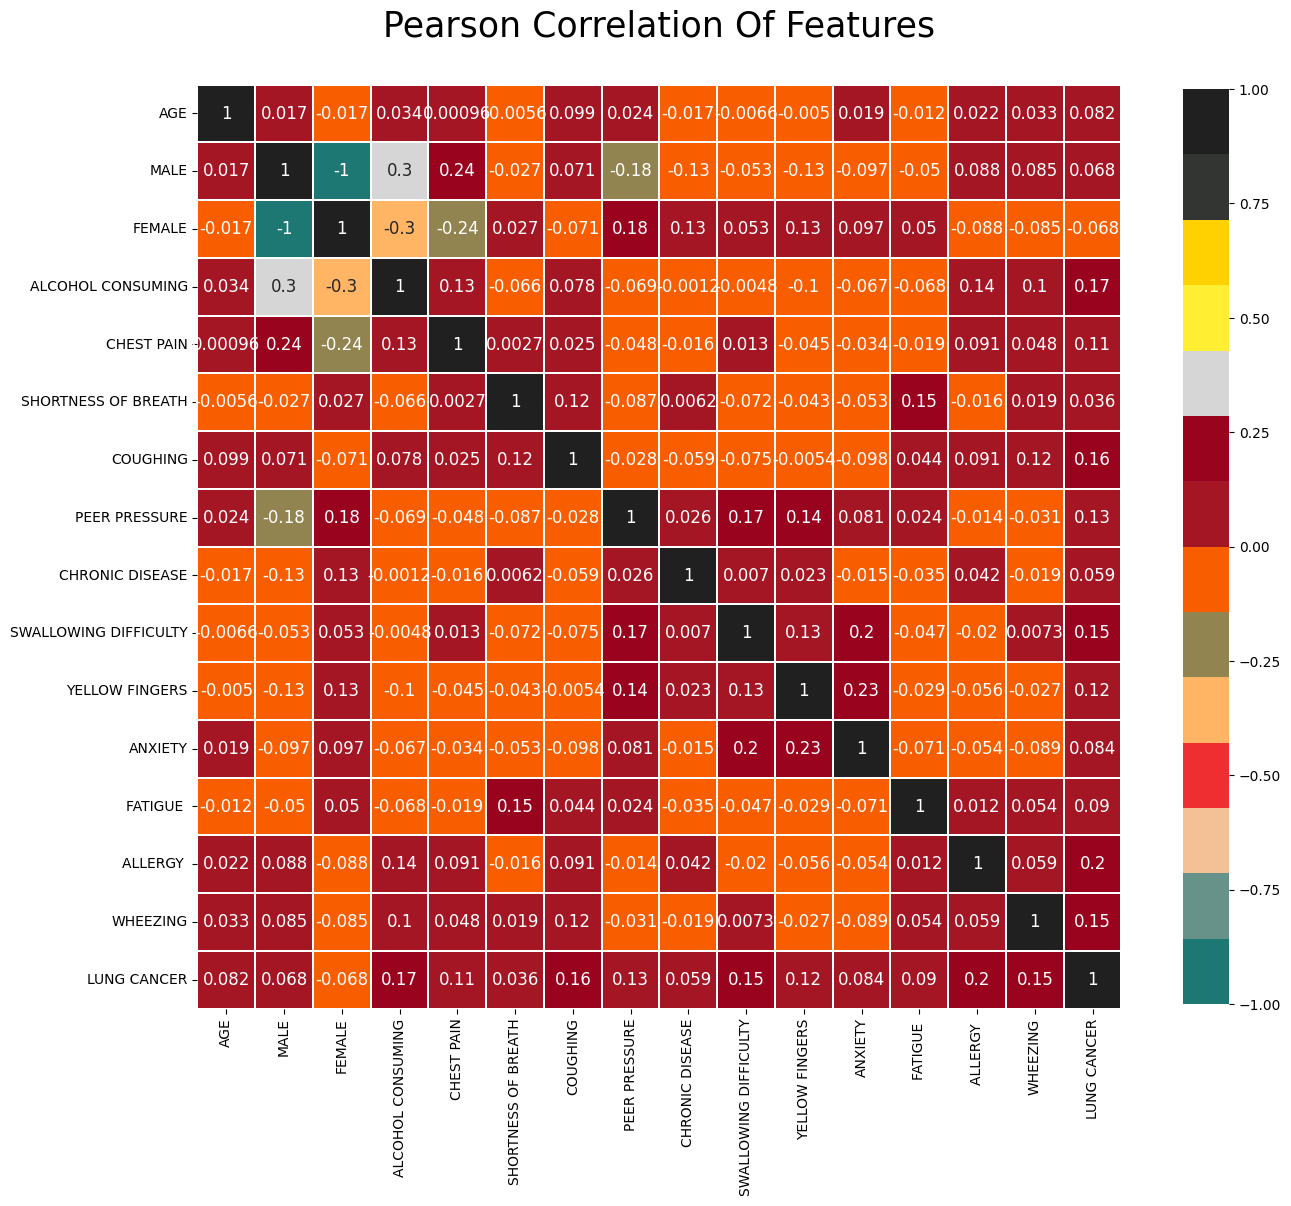

In [31]:
# Create a figure with a specified size
plt.subplots(figsize=(16, 12))

# Create a heatmap to visualize the correlation matrix of the 'data' DataFrame
p = sns.heatmap(
    df.corr(),                # Calculate the correlation matrix of the DataFrame
    cmap=palette,               # Set the color palette for the heatmap
    square=True,                # Make the heatmap square
    cbar_kws=dict(shrink=0.99), # Shrink the colorbar for better fit
    annot=True,                 # Annotate each cell with the numeric value
    vmin=-1, vmax=1,            # Set the range of the correlation scale (-1 to 1)
    linewidths=0.1,             # Set the linewidth between cells
    linecolor='white',          # Set the color of the lines between cells
    annot_kws=dict(fontsize=12) # Set the font size of the annotations
)

# Set the title of the heatmap
p.axes.set_title("Pearson Correlation Of Features\n", fontsize=25)

# Rotate the x-axis labels by 90 degrees for better readability
plt.xticks(rotation=90)

# Display the heatmap
plt.show()